> Note
>
> The canonical Sung-system walkthrough now lives in [`demo_tunable_customcircuit_sung_analysis.ipynb`](demo_tunable_customcircuit_sung_analysis.ipynb).
> This notebook is retained for compatibility and historical context.


In [39]:
using ScQubitsMimic
using CairoMakie
using LinearAlgebra
using Latexify
using Markdown
using Printf

const ELEMENTARY_CHARGE = 1.602176634e-19
const PLANCK_CONSTANT = 6.62607015e-34
const JJ_EC_NEGLIGIBLE = 1.0e6

physical_ec_from_capacitance_ff(C_ff) = ELEMENTARY_CHARGE^2 / (2 * C_ff * 1e-15 * PLANCK_CONSTANT) / 1e9
branch_ec_from_capacitance_ff(C_ff) = physical_ec_from_capacitance_ff(C_ff) / 4
flux_bias_to_rad(bias) = 2π * bias

const QB1_EJ_GHz = 12.2
const CPLR_EJ1_GHz = 46.0
const CPLR_EJ2_GHz = 25.0
const QB2_EJ1_GHz = 13.0
const QB2_EJ2_GHz = 2.8

const QB1_GROUND_BRANCH_EC = branch_ec_from_capacitance_ff(95.0)
const CPLR_GROUND_BRANCH_EC = branch_ec_from_capacitance_ff(228.0)
const QB2_GROUND_BRANCH_EC = branch_ec_from_capacitance_ff(98.0)
const QB1_CPLR_BRANCH_EC = branch_ec_from_capacitance_ff(5.36)
const CPLR_QB2_BRANCH_EC = branch_ec_from_capacitance_ff(5.36)
const QB1_QB2_BRANCH_EC = branch_ec_from_capacitance_ff(0.125)

const EXPECTED_CAPACITANCE_MATRIX = [
    2.593800082548214 -0.13835664798187222 -0.0032266009324130643;
   -0.13835664798187222 6.162033646685175 -0.13835664798187222;
   -0.0032266009324130643 -0.13835664798187222 2.671238629926127;
]

const COUPLER_FLUX_PARAM = :Φ1
const QB2_FLUX_PARAM = :Φ2
const DEFAULT_NCUT = 6
const DEFAULT_HIERARCHY = [[1], [2], [3]]
const DEFAULT_TRUNC_DIMS = [3, 3, 3]

const SUNG_EXPERIMENT_CIRCUIT = """
branches:
  - [JJ, 0, 1, EJ=$(QB1_EJ_GHz), EC=$(JJ_EC_NEGLIGIBLE)]
  - [C, 1, 0, EC=$(QB1_GROUND_BRANCH_EC)]
  - [JJ, 0, 2, EJ=$(CPLR_EJ1_GHz), EC=$(JJ_EC_NEGLIGIBLE)]
  - [JJ, 2, 0, EJ=$(CPLR_EJ2_GHz), EC=$(JJ_EC_NEGLIGIBLE)]
  - [C, 2, 0, EC=$(CPLR_GROUND_BRANCH_EC)]
  - [JJ, 0, 3, EJ=$(QB2_EJ1_GHz), EC=$(JJ_EC_NEGLIGIBLE)]
  - [JJ, 3, 0, EJ=$(QB2_EJ2_GHz), EC=$(JJ_EC_NEGLIGIBLE)]
  - [C, 3, 0, EC=$(QB2_GROUND_BRANCH_EC)]
  - [C, 1, 2, EC=$(QB1_CPLR_BRANCH_EC)]
  - [C, 2, 3, EC=$(CPLR_QB2_BRANCH_EC)]
  - [C, 1, 3, EC=$(QB1_QB2_BRANCH_EC)]
"""

function build_sung_circuit(; flux_cplr=0.0, flux_qb2=0.0, ncut=DEFAULT_NCUT)
    circ = Circuit(SUNG_EXPERIMENT_CIRCUIT; ncut=ncut)
    set_param!(circ, COUPLER_FLUX_PARAM, flux_bias_to_rad(flux_cplr))
    set_param!(circ, QB2_FLUX_PARAM, flux_bias_to_rad(flux_qb2))
    return circ
end

function build_hierarchical_hs(; flux_cplr=0.0, flux_qb2=0.0,
                               ncut=DEFAULT_NCUT,
                               trunc_dims=DEFAULT_TRUNC_DIMS)
    return hierarchical_diag(build_sung_circuit(; flux_cplr=flux_cplr, flux_qb2=flux_qb2, ncut=ncut);
        system_hierarchy=DEFAULT_HIERARCHY,
        subsystem_trunc_dims=trunc_dims)
end

function subsystem_transition_freq(subsys)
    vals = eigenvals(subsys; evals_count=2)
    return vals[2] - vals[1]
end

subsystem_w01s(hs) = (
    qb1 = subsystem_transition_freq(hs.subsystems[1]),
    cplr = subsystem_transition_freq(hs.subsystems[2]),
    qb2 = subsystem_transition_freq(hs.subsystems[3]),
)

circ1 = build_sung_circuit()


Circuit(SymbolicCircuit(CircuitGraph(Branch[Branch(JJ, 0→1, EJ=12.2, EC=1.0e6), Branch(C, 1→0, EC=0.050974287696471374), Branch(JJ, 0→2, EJ=46.0, EC=1.0e6), Branch(JJ, 2→0, EJ=25.0, EC=1.0e6), Branch(C, 2→0, EC=0.021239286540196405), Branch(JJ, 0→3, EJ=13.0, EC=1.0e6), Branch(JJ, 3→0, EJ=2.8, EC=1.0e6), Branch(C, 3→0, EC=0.04941385031800796), Branch(C, 1→2, EC=0.9034621886501454), Branch(C, 2→3, EC=0.9034621886501454), Branch(C, 1→3, EC=38.74045864931824)], 3, true), [2, 5, 8], [1, 3, 4, 6, 7, 9, 10, 11], [[(1, 1), (2, 1)], [(3, 1), (5, 1)], [(4, 1), (5, -1)], [(6, 1), (8, 1)], [(7, 1), (8, -1)], [(9, 1), (2, -1), (5, 1)], [(10, 1), (5, -1), (8, 1)], [(11, 1), (2, -1), (8, 1)]], [4, 7], [[(4, 1), (3, 1)], [(7, 1), (6, 1)]], Symbolics.Num[φ₁, φ₂, φ₃], Symbolics.Num[φ̇₁, φ̇₂, φ̇₃], Symbolics.Num[2.593800082548214 -0.13835664798187222 -0.0032266009324130643; -0.13835664798187222 6.162033646685175 -0.13835664798187222; -0.0032266009324130643 -0.13835664798187222 2.671238629926127], Symboli

# Tunable Custom Circuit Analysis

This notebook refactors the custom-circuit walkthrough around the **Sung et al.** experimental device from
*“Realization of high-fidelity CZ and ZZ-free iSWAP gates with a tunable coupler”*.

**Source note**
- This is **not** the 2018 PR Applied tunable-coupler scheme paper.
- Fig. 7 supplies the fitted Josephson energies for `QB1`, `CPLR`, and `QB2`.
- Appendix Q / Table VI supplies the physical capacitances `C1`, `Cc`, `C2`, `C1c`, `C2c`, and `C12`.
- In `ScQubitsMimic`, branch `EC` encodes branch capacitance through `C = 1 / (8 EC)`, so a physical capacitance `C` becomes a branch input `EC_branch = (e^2 / 2 C h) / 4`.
- With fixed-frequency `QB1`, the generated external flux symbols are `Φ1` for the coupler loop and `Φ2` for the `QB2` loop.


## Circuit Definition And Translation

The circuit below uses explicit `C` branches to represent the Sung et al. Table VI capacitance matrix and keeps JJ-branch capacitance negligible.
This preserves the paper topology `fixed QB1 + tunable CPLR + tunable QB2` while remaining faithful to the codebase branch-capacitance convention.


In [40]:
    println("Paper-derived branch inputs (GHz):")
    println((
        qb1_ground = QB1_GROUND_BRANCH_EC,
        cplr_ground = CPLR_GROUND_BRANCH_EC,
        qb2_ground = QB2_GROUND_BRANCH_EC,
        qb1_cplr = QB1_CPLR_BRANCH_EC,
        cplr_qb2 = CPLR_QB2_BRANCH_EC,
        qb1_qb2 = QB1_QB2_BRANCH_EC,
    ))
    println("External flux symbols: ", external_fluxes(circ1))
    println("Flux loop map: ", sym_external_fluxes(circ1))
    println("Offset-charge symbols: ", offset_charges(circ1))
    println("Variable categories: ", circ1.var_categories)

    C_numeric = ScQubitsMimic._build_capacitance_matrix_numeric(circ1)
    println("Numeric capacitance matrix:\n", C_numeric)
    println("Max |ΔC| vs translated target = ", maximum(abs.(C_numeric .- EXPECTED_CAPACITANCE_MATRIX)))

    @assert length(external_fluxes(circ1)) == 2
    @assert maximum(abs.(C_numeric .- EXPECTED_CAPACITANCE_MATRIX)) < 1e-12


Paper-derived branch inputs (GHz):
(qb1_ground = 0.050974287696471374, cplr_ground = 0.021239286540196405, qb2_ground = 0.04941385031800796, qb1_cplr = 0.9034621886501454, cplr_qb2 = 0.9034621886501454, qb1_qb2 = 38.74045864931824)
External flux symbols: Symbolics.Num[Φ1, Φ2]
Flux loop map: Dict{Symbolics.Num, @NamedTuple{closure_branch::Int64, loop::Vector{Tuple{Int64, Int64}}}}(Φ1 => (closure_branch = 4, loop = [(4, 1), (3, 1)]), Φ2 => (closure_branch = 7, loop = [(7, 1), (6, 1)]))
Offset-charge symbols: Symbolics.Num[ng1, ng2, ng3]
Variable categories: VarCategories(periodic=[1, 2, 3], extended=Int64[], free=Int64[], frozen=Int64[])
Numeric capacitance matrix:
[2.593800082548214 -0.13835664798187222 -0.0032266009324130643; -0.13835664798187222 6.162033646685175 -0.13835664798187222; -0.0032266009324130643 -0.13835664798187222 2.671238629926127]
Max |ΔC| vs translated target = 0.0


## Symbolic Lagrangian And Hamiltonian

As in the scqubits custom-circuit tutorial, the first step is to inspect the symbolic model before moving on to hierarchical sweeps.


In [41]:
sym_lagrangian(circ1; vars_type=:node)


2.8cos(Φ2 - φ₃) + 25.0cos(Φ1 - φ₂) + 12.2cos(φ₁) + 13.0cos(φ₃) + 46.0cos(φ₂) + (2.593800082548214(φ̇₁^2) - 0.27671329596374444φ̇₁*φ̇₂ - 0.006453201864826129φ̇₁*φ̇₃ + 6.162033646685175(φ̇₂^2) - 0.27671329596374444φ̇₂*φ̇₃ + 2.671238629926127(φ̇₃^2)) / 2

In [42]:
variable_transformation(circ1)
circ1.var_categories


VarCategories(periodic=[1, 2, 3], extended=Int64[], free=Int64[], frozen=Int64[])

In [43]:
sym_hamiltonian(circ1; return_expr=true)


-46.0cos(θ₂) - 2.8cos(Φ2 / 6.283185307179586 - θ₃) - 13.0cos(θ₃) - 12.2cos(θ₁) - 25.0cos(Φ1 / 6.283185307179586 - θ₂) + 0.771999(nθ₁^2) + 0.03475nθ₁*nθ₂ + 0.003665nθ₁*nθ₃ + 0.325337(nθ₂^2) + 0.033744nθ₂*nθ₃ + 0.749592(nθ₃^2)

## Configured Subsystem Introspection

`configure!` attaches a subsystem hierarchy to the circuit and lets us inspect the individual `QB1`, `CPLR`, and `QB2` symbolic Hamiltonians and their pairwise interactions.


In [44]:
circ_cfg = build_sung_circuit(; ncut=6)
configure!(circ_cfg;
    system_hierarchy=DEFAULT_HIERARCHY,
    subsystem_trunc_dims=DEFAULT_TRUNC_DIMS)

subsystem_exprs = [
    "QB1" => sym_hamiltonian(circ_cfg; subsystem_index=1, return_expr=true),
    "CPLR" => sym_hamiltonian(circ_cfg; subsystem_index=2, return_expr=true),
    "QB2" => sym_hamiltonian(circ_cfg; subsystem_index=3, return_expr=true),
]

interaction_exprs = [
    "QB1-CPLR" => sym_interaction(circ_cfg; subsystem_indices=(1, 2), return_expr=true),
    "CPLR-QB2" => sym_interaction(circ_cfg; subsystem_indices=(2, 3), return_expr=true),
    "QB1-QB2" => sym_interaction(circ_cfg; subsystem_indices=(1, 3), return_expr=true),
]

subsystem_exprs, interaction_exprs


(Pair{String, Symbolics.Num}["QB1" => -12.2cos(θ₁) + 0.771999(nθ₁^2), "CPLR" => -46.0cos(θ₂) - 25.0cos(Φ1 / 6.283185307179586 - θ₂) + 0.325337(nθ₂^2), "QB2" => -2.8cos(Φ2 / 6.283185307179586 - θ₃) - 13.0cos(θ₃) + 0.749592(nθ₃^2)], Pair{String, Symbolics.Num}["QB1-CPLR" => 0.03475nθ₁*nθ₂, "CPLR-QB2" => 0.033744nθ₂*nθ₃, "QB1-QB2" => 0.003665nθ₁*nθ₃])

## Hierarchical Frequency Sweeps

The paper-faithful custom circuit has two tunable loops. The generated symbols are `Φ1` for the coupler loop and `Φ2` for the right-qubit loop.
We sweep each one separately on a monotonic half-branch and overlay the subsystem `ω01` frequencies.


In [48]:
const DEFAULT_BIAS_WINDOW = collect(range(-0.6, 0.6; length=101))

function sweep_subsystem_frequencies(bias_vals=DEFAULT_BIAS_WINDOW; swept=:cplr,
                                     ncut=DEFAULT_NCUT,
                                     trunc_dims=DEFAULT_TRUNC_DIMS)
    rows = NamedTuple[]
    for bias in bias_vals
        hs = swept === :cplr ?
            build_hierarchical_hs(; flux_cplr=bias, flux_qb2=0.0, ncut=ncut, trunc_dims=trunc_dims) :
            build_hierarchical_hs(; flux_cplr=0.0, flux_qb2=bias, ncut=ncut, trunc_dims=trunc_dims)
        push!(rows, merge((flux_bias=bias, swept=swept), subsystem_w01s(hs)))
    end
    return rows
end

sweep_cplr = sweep_subsystem_frequencies(; swept=:cplr)
sweep_qb2 = sweep_subsystem_frequencies(; swept=:qb2)

println("Center-point subsystem ω01 values (GHz): ", subsystem_w01s(build_hierarchical_hs()))
println("Coupler sweep range (GHz): ", extrema(getfield.(sweep_cplr, :cplr)))
println("QB2 sweep range (GHz): ", extrema(getfield.(sweep_qb2, :qb2)))


Center-point subsystem ω01 values (GHz): (qb1 = 4.137383287875743, cplr = 7.620785599076555, qb2 = 4.671706001032064)
Coupler sweep range (GHz): (3.6423591533655255, 7.620785599076555)
QB2 sweep range (GHz): (3.7129293338834763, 4.671706001032064)


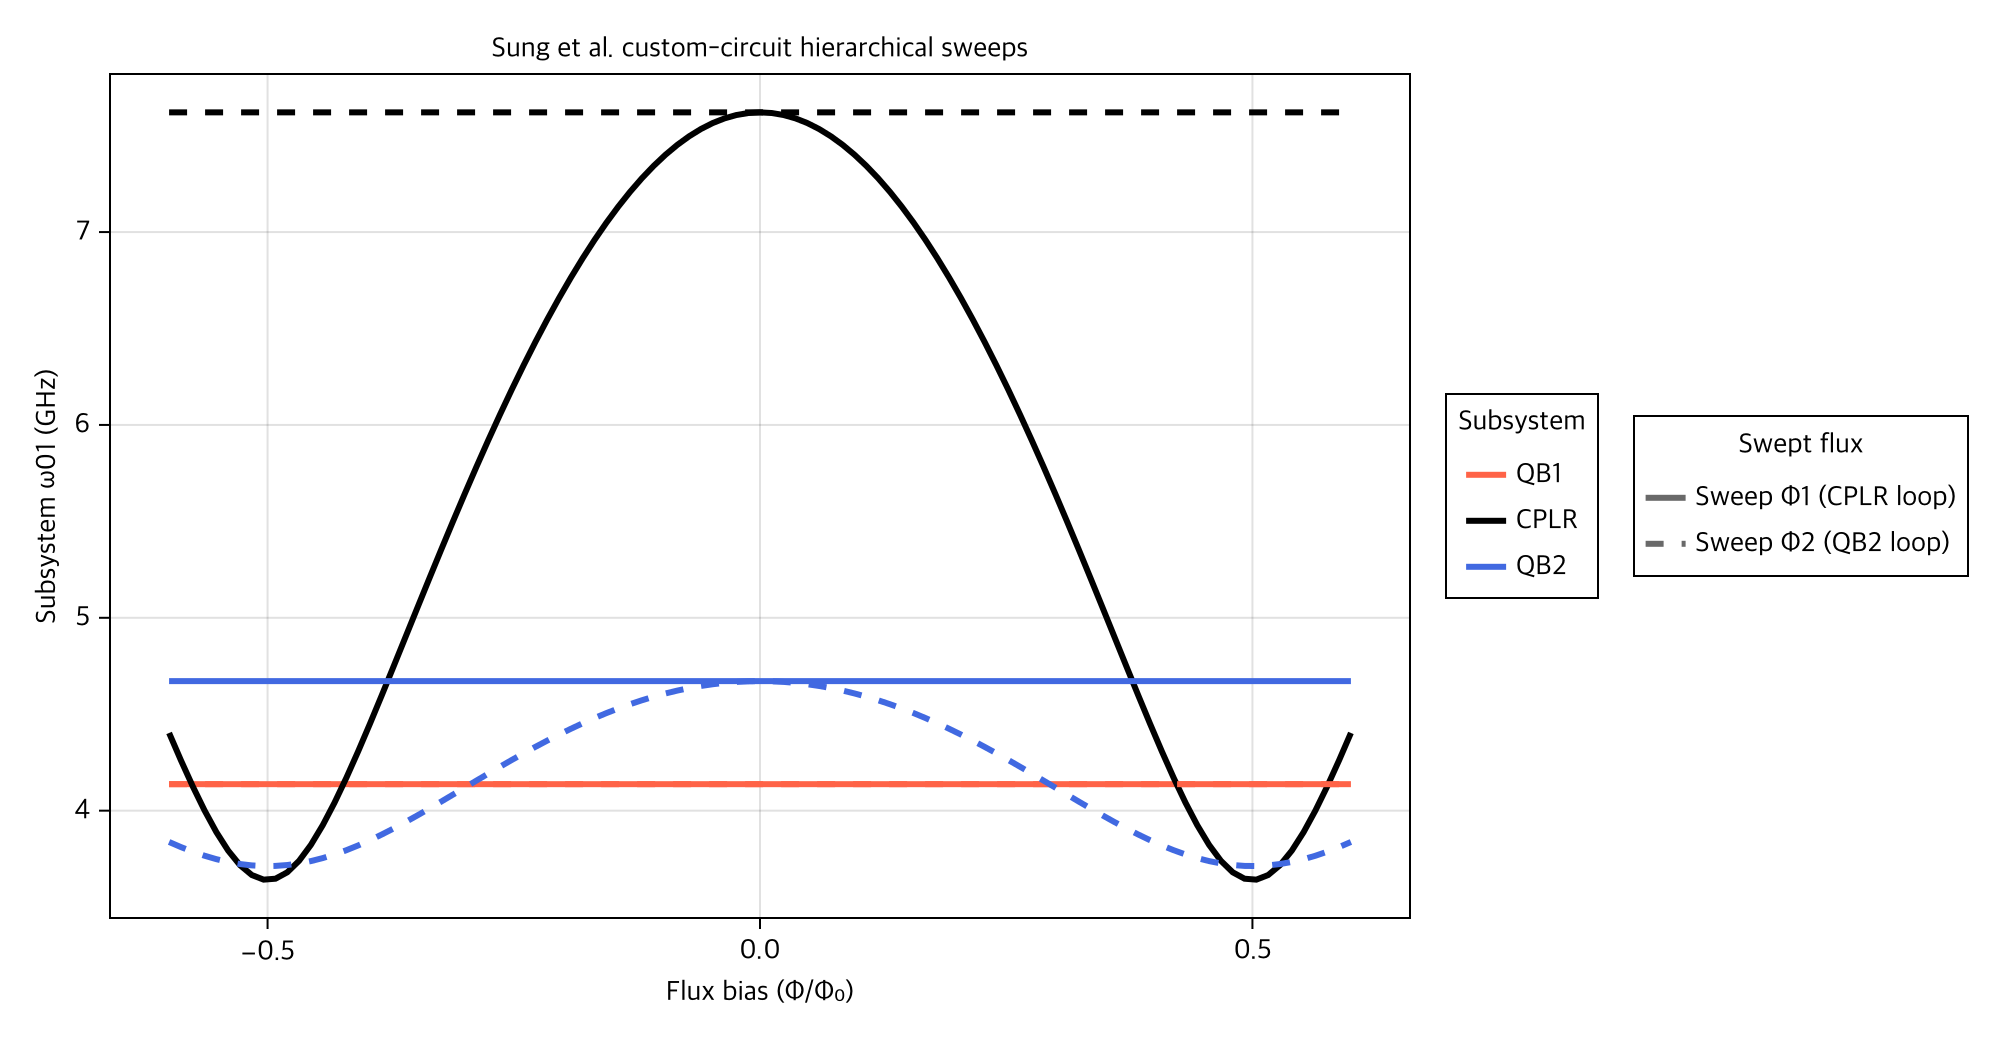

In [49]:
fig = Figure(size=(1000, 520))
ax = Axis(fig[1, 1];
    xlabel="Flux bias (Φ/Φ₀)",
    ylabel="Subsystem ω01 (GHz)",
    title="Sung et al. custom-circuit hierarchical sweeps")

colors = Dict(:qb1 => :tomato, :cplr => :black, :qb2 => :royalblue)
linestyles = Dict(:cplr => :solid, :qb2 => :dash)
labels = Dict(:qb1 => "QB1", :cplr => "CPLR", :qb2 => "QB2")

for rows in (sweep_cplr, sweep_qb2)
    sweep_name = rows[1].swept
    xs = getfield.(rows, :flux_bias)
    for field in (:qb1, :cplr, :qb2)
        ys = getfield.(rows, field)
        lines!(ax, xs, ys; color=colors[field], linestyle=linestyles[sweep_name], linewidth=3)
    end
end

color_legend = [LineElement(color=colors[field], linewidth=3) for field in (:qb1, :cplr, :qb2)]
style_legend = [LineElement(color=:dimgray, linestyle=linestyles[name], linewidth=3) for name in (:cplr, :qb2)]

Legend(fig[1, 2], color_legend, [labels[field] for field in (:qb1, :cplr, :qb2)], "Subsystem")
Legend(fig[1, 3], style_legend, ["Sweep Φ1 (CPLR loop)", "Sweep Φ2 (QB2 loop)"], "Swept flux")

fig


## Direct vs Hierarchical Spectrum At One Bias Point

A single zero-bias check compares the low-lying direct-diagonalization spectrum with the hierarchical composite spectrum used for the subsystem analysis.


In [47]:
circ_center = build_sung_circuit(; ncut=DEFAULT_NCUT)
full_center = eigenvals(circ_center; evals_count=4)
hs_center = build_hierarchical_hs()
hier_center = eigenvals(hs_center; evals_count=4)

center_summary = (
    direct_relative_levels_GHz = full_center .- full_center[1],
    hierarchical_relative_levels_GHz = hier_center .- hier_center[1],
    subsystem_w01_GHz = subsystem_w01s(hs_center),
)

center_summary


(direct_relative_levels_GHz = [0.0, 4.134715786796534, 4.668409282213858, 7.62509083474626], hierarchical_relative_levels_GHz = [0.0, 4.134718753892585, 4.6684119566482, 7.625096043628147], subsystem_w01_GHz = (qb1 = 4.137383287875743, cplr = 7.620785599076555, qb2 = 4.671706001032064))